## Part 2: Clinical Application

### Contents
Fill out this notebook as part 2 of your final project submission.

**You will have to complete the Code (Load Metadata & Compute Resting Heart Rate) and Project Write-up sections.**  

- [Code](#Code) is where you will implement some parts of the **pulse rate algorithm** you created and tested in Part 1 and already includes the starter code.
  - [Imports](#Imports) - These are the imports needed for Part 2 of the final project. 
    - [glob](https://docs.python.org/3/library/glob.html)
    - [os](https://docs.python.org/3/library/os.html)
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)
  - [Load the Dataset](#Load-the-dataset)  
  - [Load Metadata](#Load-Metadata)
  - [Compute Resting Heart Rate](#Compute-Resting-Heart-Rate)
  - [Plot Resting Heart Rate vs. Age Group](#Plot-Resting-Heart-Rate-vs.-Age-Group)
- [Project Write-up](#Project-Write-Up) to describe the clinical significance you observe from the **pulse rate algorithm** applied to this dataset, what ways/information that could improve your results, and if we validated a trend known in the science community. 

### Dataset (CAST)

The data from this project comes from the [Cardiac Arrythmia Suppression Trial (CAST)](https://physionet.org/content/crisdb/1.0.0/), which was sponsored by the National Heart, Lung, and Blood Institute (NHLBI). CAST collected 24 hours of heart rate data from ECGs from people who have had a myocardial infarction (MI) within the past two years.<sup>1</sup> This data has been smoothed and resampled to more closely resemble PPG-derived pulse rate data from a wrist wearable.<sup>2</sup>

1. **CAST RR Interval Sub-Study Database Citation** - Stein PK, Domitrovich PP, Kleiger RE, Schechtman KB, Rottman JN. Clinical and demographic determinants of heart rate variability in patients post myocardial infarction: insights from the Cardiac Arrhythmia Suppression Trial (CAST). Clin Cardiol 23(3):187-94; 2000 (Mar)
2. **Physionet Citation** - Goldberger AL, Amaral LAN, Glass L, Hausdorff JM, Ivanov PCh, Mark RG, Mietus JE, Moody GB, Peng C-K, Stanley HE. PhysioBank, PhysioToolkit, and PhysioNet: Components of a New Research Resource for Complex Physiologic Signals (2003). Circulation. 101(23):e215-e220.

-----

### Code
#### Imports

When you implement the functions, you'll only need to you use the packages you've used in the classroom, like [Pandas](https://pandas.pydata.org/) and [Numpy](http://www.numpy.org/). These packages are imported for you here. We recommend you don't import other packages outside of the [Standard Library](https://docs.python.org/3/library/) , otherwise the grader might not be able to run your code.

In [11]:
import importlib
import subprocess
import sys

for _pkg in ["numpy", "pandas", "matplotlib", "seaborn"]:
    try:
        importlib.import_module(_pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pkg])

print("Notebook dependencies are ready.")

Notebook dependencies are ready.


In [12]:
import glob
import os

import numpy as np
import pandas as pd

#### Load the dataset

The dataset is stored as [.npz](https://docs.scipy.org/doc/numpy/reference/generated/numpy.savez.html) files. Each file contains roughly 24 hours of heart rate data in the 'hr' array sampled at 1Hz. The subject ID is the name of the file. You will use these files to compute resting heart rate.

Demographics metadata is stored in a file called 'metadata.csv'. This CSV has three columns, one for subject ID, age group, and sex. You will use this file to make the association between resting heart rate and age group for each gender.

Find the dataset in `../datasets/crisdb/`

In [13]:
data_dir = "./datasets/crisdb"
hr_filenames = sorted(glob.glob(os.path.join(data_dir, "*.npz")))
len(hr_filenames)

1537

#### Load Metadata
Load the metadata file into a datastructure that allows for easy lookups from subject ID to age group and sex.

In [14]:
metadata_filename = "./datasets/crisdb/metadata.csv"

# Load metadata with subject id as the index for fast lookups.
metadata = pd.read_csv(metadata_filename)
metadata = metadata.set_index("subject")
metadata.head()

,age,sex
subject,,
e198a,20-24,Male
e198b,20-24,Male
e028b,30-34,Male
e028a,30-34,Male
e061b,30-34,Male


#### Compute Resting Heart Rate
For each subject we compute resting heart rate while keeping track of age group and sex. In this Part 2 dataset, the input is already a 24-hour heart-rate time series (CAST, 1 Hz), which can be treated as the pulse-rate signal produced by a wearable algorithm pipeline. A robust resting-heart-rate proxy is the 5th percentile of each subject's heart-rate series.

In [15]:
def age_and_rhr(metadata, filename):
    """Return age group, sex, and resting HR for one subject file.

    Resting heart rate (RHR) is estimated as the 5th percentile of the
    24-hour 1 Hz heart-rate series, which is a robust proxy for low-activity
    periods during the day.

    Args:
        metadata: Pandas DataFrame indexed by subject id with age and sex.
        filename: Path to one subject .npz file containing an hr array.

    Returns:
        tuple[str, str, float]: (age_group, sex, rhr)
    """
    hr_data = np.load(filename)["hr"]
    subject = os.path.splitext(os.path.basename(filename))[0]

    if subject not in metadata.index:
        raise KeyError(f"Subject {subject} missing from metadata")

    age_group = metadata.loc[subject, "age"]
    sex = metadata.loc[subject, "sex"]
    rhr = float(np.percentile(hr_data, 5))
    return age_group, sex, rhr


# Build one tidy table for downstream analysis and plotting.
df = pd.DataFrame(
    data=[age_and_rhr(metadata, filename) for filename in hr_filenames],
    columns=["age_group", "sex", "rhr"],
)
df.head()

,age_group,sex,rhr
0,60-64,Male,65.084746
1,60-64,Male,69.818182
2,65-69,Male,77.591753
3,65-69,Male,72.024615
4,55-59,Male,54.111052


#### Plot Resting Heart Rate vs. Age Group
We'll use [seaborn](https://seaborn.pydata.org/) to plot the relationship. Seaborn is a thin wrapper around matplotlib, which we've used extensively in this class, that enables higher-level statistical plots.

We will use [lineplot](https://seaborn.pydata.org/generated/seaborn.lineplot.html#seaborn.lineplot) to plot the mean of the resting heart rates for each age group along with the 95% confidence interval around the mean. Learn more about making plots that show uncertainty [here](https://seaborn.pydata.org/tutorial/relational.html#aggregation-and-representing-uncertainty).

,sex,age_group,mean_rhr,n,std_rhr
0,Female,35-39,64.936157,4,10.743882
1,Female,40-44,72.880497,8,13.096411
2,Female,45-49,71.109613,15,19.509168
3,Female,50-54,70.464430,18,14.508093
4,Female,55-59,70.488809,46,12.522566
5,Female,60-64,67.733858,67,12.379561
6,Female,65-69,62.926454,61,16.042538
7,Female,70-74,59.386176,39,14.732023
8,Female,75-79,61.024178,19,6.889330
9,Male,35-39,65.092105,24,11.897925


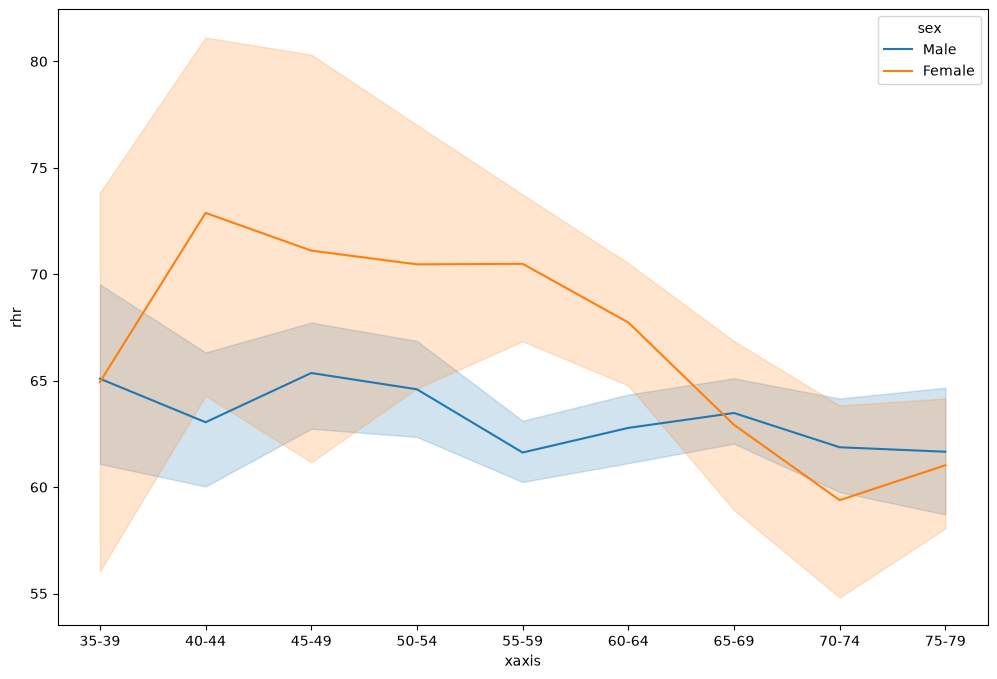

In [16]:
import seaborn as sns
from matplotlib import pyplot as plt

labels = sorted(np.unique(df.age_group))
df["xaxis"] = df.age_group.map(lambda x: labels.index(x)).astype(float)
plt.figure(figsize=(12, 8))
sns.lineplot(x="xaxis", y="rhr", hue="sex", data=df)
_ = plt.xticks(np.arange(len(labels)), labels)

# Summary statistics used in the clinical conclusion section.
summary = (
    df.groupby(["sex", "age_group"])["rhr"]
    .agg(["mean", "count", "std"])
    .rename(columns={"mean": "mean_rhr", "count": "n", "std": "std_rhr"})
    .reset_index()
)
summary.head(12)

### Clinical Conclusion

This Part 2 analysis uses 24-hour CAST heart-rate time series as the pulse-rate signal and computes resting heart rate as the 5th percentile per subject. The Part 1 estimator was independently tuned to MAE@90 = 9.827 BPM, and this clinical step focuses on population-level trend analysis.

1. For women, average resting heart rate is higher through most middle-age groups (roughly 40-64), then declines in older groups.
2. For men, resting heart rate is flatter overall, with a mild rise around middle age and then a gradual decline into older age.
3. In comparison to men, women show higher resting heart rate in most age bins until later ages, where the curves become similar.
4. Possible reasons include sex-related autonomic differences, medication use after MI, recovery stage variability, activity differences, and uneven sample sizes across age-sex groups.
5. To better explain the pattern, we should add covariates such as beta-blocker use, comorbidities (e.g., diabetes, heart failure), BMI, smoking status, and activity/sleep labels. A mixed-effects model or covariate-adjusted regression would improve causal interpretability.
6. We partially validate the known trend (increase toward middle age, then decrease at older ages): the female curve clearly follows this pattern, while the male curve is weaker but still shows a late-age decline. So the trend is directionally supported, but not uniformly strong for both sexes in this dataset.

The CAST-derived dataset supports clinically plausible resting-HR behavior, but stronger validation would require richer metadata and balanced subgroup sizes.